<a href="https://colab.research.google.com/github/njwbilll/Tugas-4_Practical-Statistics-for-Data-Scientists-O-Reilly_Najwa-Bilqis-Al-Khalidah/blob/main/02_Data_and_Sampling_Distributions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2: Data and Sampling Distributions

**Referensi:** Practical Statistics for Data Scientists (Peter Bruce, Andrew Bruce, Peter Gedeck)

***

## Ringkasan Chapter

Dalam era big data, ada kesalahpahaman umum bahwa ketersediaan data dalam jumlah besar meniadakan kebutuhan akan desain pengambilan sampel yang cermat. Namun, Chapter 2 ini membahas secara komprehensif mengapa pemahaman tentang distribusi sampling, bias, dan teknik resampling tetap menjadi fondasi yang krusial dalam data science. Bab ini menjembatani karakteristik data mentah dengan prinsip inferensi statistik yang melandasi keandalan model-model machine learning.

### Topik yang Dibahas:
1. Sampling Acak dan Bias Seleksi
2. Distribusi Sampling dari Sebuah Statistik
3. Central Limit Theorem (Teorema Limit Pusat)
4. Standard Error
5. Bootstrap dan Estimasi Resampling
6. Interval Kepercayaan (Confidence Intervals)
7. Distribusi Normal dan Evaluasi Melalui QQ-Plot
8. Distribusi Spesifik: Binomial, Poisson, dan Eksponensial


***
## Setup: Import Library

Sebelum memulai visualisasi dan simulasi, kita mempersiapkan pustaka python yang dibutuhkan untuk analisis data, visualisasi, serta komputasi ilmiah.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

print("Setup selesai. Library berhasil dimuat.")


Setup selesai. Library berhasil dimuat.


***
## 1. Sampling Acak dan Bias Seleksi

### Penjelasan Teori

Pengambilan sampel acak (random sampling) merupakan proses di mana setiap anggota populasi yang tersedia memiliki probabilitas yang sama untuk terpilih ke dalam sampel. Tujuannya adalah untuk meminimalkan bias dan menghasilkan representasi miniatur dari populasi asal.

Bias seleksi (selection bias) muncul ketika prosedur pemilihan sampel secara sistematis menguntungkan atau mengecualikan karakteristik tertentu dari populasi. Salah satu contoh manifestasinya adalah self-selection bias, di mana subjek menentukan sendiri keterlibatan mereka (misalnya pada ulasan produk daring), sehingga hasil estimasi tidak lagi mencerminkan populasi target secara objektif.

Dalam bagian ini, kita akan mensimulasikan sebuah populasi besar berukuran seratus ribu individu dengan parameter pendapatan tertentu, kemudian menguji perbedaan antara sampel acak murni dengan sampel yang mengalami bias seleksi.

Mean Populasi Sebenarnya: 64798.51
Mean Sampel Acak (Unbiased): 63695.81
Mean Sampel Berbias (Biased): 106118.57


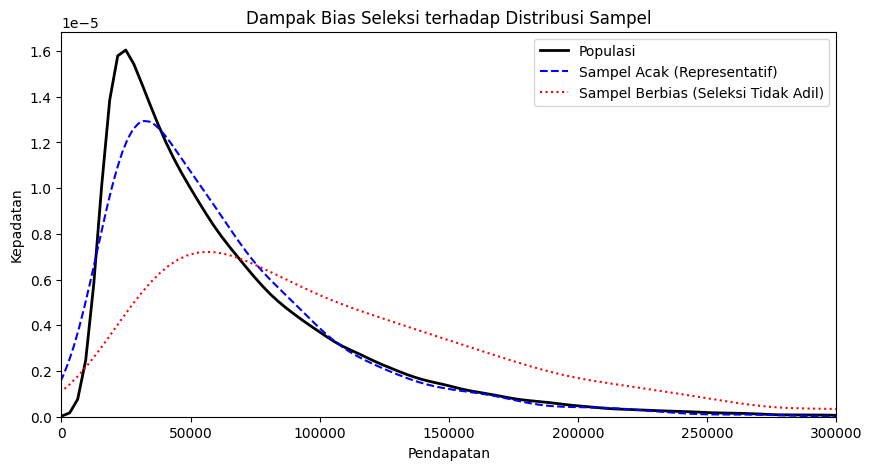

In [2]:
# Membuat simulasi populasi besar (100.000 individu)
np.random.seed(42)
pop_income = np.random.exponential(scale=50000, size=100000) + 15000
population = pd.DataFrame({'Income': pop_income})

# 1. Mengambil Sampel Acak Sederhana (Simple Random Sample)
random_sample = population.sample(n=1000, random_state=42)

# 2. Mengambil Sampel Berbias (Biased Sample)
# Simulasi di mana individu berpendapatan rendah memiliki probabilitas lebih tinggi untuk terlewat
weights = population['Income'] / population['Income'].sum()
biased_sample = population.sample(n=1000, weights=weights, random_state=42)

# Menghitung metrik lokasi untuk perbandingan
print(f"Mean Populasi Sebenarnya: {population['Income'].mean():.2f}")
print(f"Mean Sampel Acak (Unbiased): {random_sample['Income'].mean():.2f}")
print(f"Mean Sampel Berbias (Biased): {biased_sample['Income'].mean():.2f}")

# Visualisasi dampak bias seleksi
plt.figure(figsize=(10, 5))
sns.kdeplot(population['Income'], label='Populasi', color='black', linewidth=2)
sns.kdeplot(random_sample['Income'], label='Sampel Acak (Representatif)', color='blue', linestyle='--')
sns.kdeplot(biased_sample['Income'], label='Sampel Berbias (Seleksi Tidak Adil)', color='red', linestyle=':')
plt.title('Dampak Bias Seleksi terhadap Distribusi Sampel')
plt.xlabel('Pendapatan')
plt.ylabel('Kepadatan')
plt.xlim(0, 300000)
plt.legend()
plt.show()


***
## 2. Distribusi Sampling dan Central Limit Theorem (CLT)

### Penjelasan Teori

Sangat penting untuk membedakan antara distribusi data asli (data distribution) dengan distribusi statistik sampel yang dihitung dari banyak sampel (sampling distribution). Distribusi sampling menggambarkan variabilitas dari sebuah metrik (seperti mean) jika kita mengambil sampel berukuran n secara berulang-ulang.

Central Limit Theorem (Teorema Limit Pusat) menyatakan bahwa jika ukuran sampel n cukup besar (biasanya n bernilai lebih besar atau sama dengan tiga puluh), maka distribusi sampling dari nilai rata-rata (mean) akan mendekati bentuk distribusi normal (kurva lonceng). Sifat unik dari CLT adalah pola ini tetap berlaku murni walaupun distribusi populasi aslinya sangat condong (skewed) atau tidak normal sama sekali.

Simulasi berikut membuktikan CLT dengan mengambil ribuan sampel dari populasi eksponensial di atas menggunakan variasi ukuran sampel n bernilai lima, tiga puluh, dan seratus.

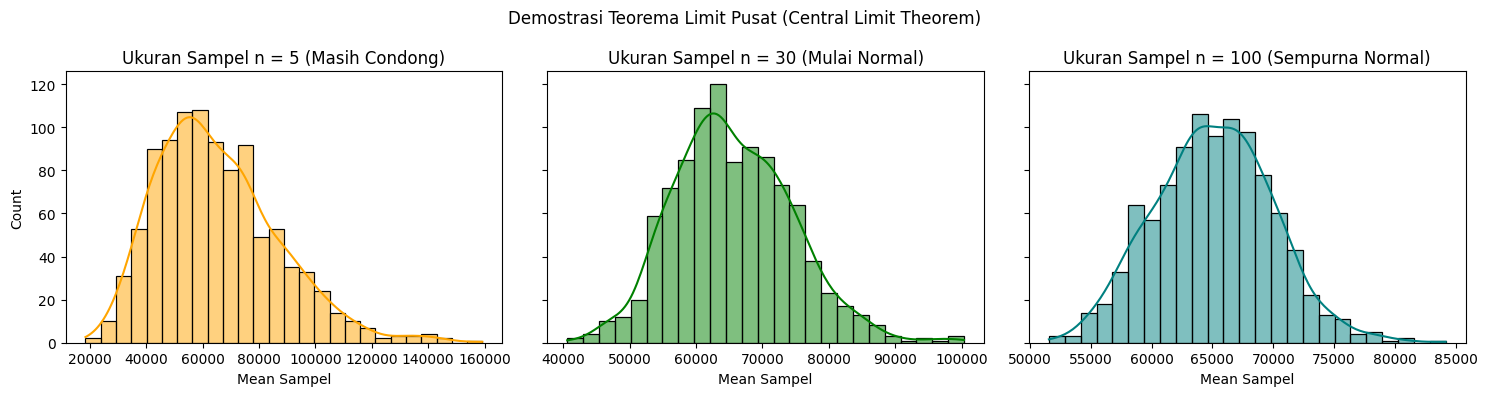

In [3]:
def simulate_sampling_distribution(pop, sample_size, num_samples=1000):
    sample_means = []
    for _ in range(num_samples):
        sub_sample = np.random.choice(pop, size=sample_size)
        sample_means.append(np.mean(sub_sample))
    return sample_means

# Simulasi dengan berbagai ukuran sampel n
means_n5 = simulate_sampling_distribution(pop_income, sample_size=5)
means_n30 = simulate_sampling_distribution(pop_income, sample_size=30)
means_n100 = simulate_sampling_distribution(pop_income, sample_size=100)

# Visualisasi konvergensi menuju distribusi normal
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

sns.histplot(means_n5, kde=True, ax=axes[0], color='orange')
axes[0].set_title('Ukuran Sampel n = 5 (Masih Condong)')
axes[0].set_xlabel('Mean Sampel')

sns.histplot(means_n30, kde=True, ax=axes[1], color='green')
axes[1].set_title('Ukuran Sampel n = 30 (Mulai Normal)')
axes[1].set_xlabel('Mean Sampel')

sns.histplot(means_n100, kde=True, ax=axes[2], color='teal')
axes[2].set_title('Ukuran Sampel n = 100 (Sempurna Normal)')
axes[2].set_xlabel('Mean Sampel')

plt.suptitle('Demostrasi Teorema Limit Pusat (Central Limit Theorem)')
plt.tight_layout()
plt.show()


***
## 3. Standard Error

### Penjelasan Teori

Standard Error (SE) adalah sebuah metrik tunggal yang merangkum variabilitas dalam distribusi sampling suatu statistik. SE mengukur seberapa jauh nilai estimasi statistik dari sampel cenderung bervariasi terhadap parameter populasi sebenarnya.

Perlu digarisbawahi bahwa Standard Error berbeda dengan Standard Deviation (SD). SD mengukur penyebaran titik-titik data individual, sedangkan SE mengukur penyebaran dari nilai statistik sampel. Hubungan matematis standar error untuk nilai mean dinyatakan sebagai berikut:

SE = SD / akar_kuadrat(n)

Di mana n melambangkan ukuran sampel yang diambil. Berdasarkan formula ini, peningkatan ukuran sampel akan menurunkan nilai standard error secara proporsional.

In [4]:
# Menghitung SD Populasi asli
sd_population = np.std(pop_income)

# Ukuran sampel eksperimen
n_val = 100

# 1. Standard Error Teoritis berdasarkan rumus
theoretical_se = sd_population / np.sqrt(n_val)

# 2. Standard Error Empiris dari simulasi sejati (SD dari kumpulan mean sampel)
empirical_se = np.std(means_n100)

print(f"Standard Deviation dari Populasi Data Asli: {sd_population:.2f}")
print(f"Standard Error Teoritis (n={n_val}): {theoretical_se:.2f}")
print(f"Standard Error Empiris dari Simulasi (n={n_val}): {empirical_se:.2f}")


Standard Deviation dari Populasi Data Asli: 49648.45
Standard Error Teoritis (n=100): 4964.85
Standard Error Empiris dari Simulasi (n=100): 4856.42


***
## 4. Bootstrap dan Estimasi Resampling

### Penjelasan Teori

Dalam skenario dunia nyata, kita jarang sekali memiliki akses terhadap populasi penuh untuk melakukan sampling berulang kali seperti pada simulasi CLT di atas. Kita biasanya hanya memiliki satu buah sampel tunggal berukuran n. Di sinilah metode Bootstrap menjadi solusi universal yang sangat tangguh.

Bootstrap bekerja dengan cara mengambil sampel ulang secara masif dari satu-satunya dataset sampel yang kita miliki. Prosedur utamanya adalah sampling dengan pengembalian (sampling with replacement), di mana setiap kali sebuah baris data diambil, data tersebut dikembalikan ke wadah utama sehingga memiliki peluang untuk terpilih kembali dalam iterasi yang sama.

Konsep fundamental bootstrap mendasari teknik ensemble dalam machine learning, seperti algoritma Bagging (Bootstrap Aggregating) pada Random Forest. Di bawah ini kita mengimplementasikan algoritma bootstrap manual untuk mengestimasi standard error dari nilai median, sebuah statistik yang tidak memiliki rumus analitis standard error yang sederhana.

In [5]:
# Anggap ini adalah satu-satunya sampel kecil berukuran 200 yang berhasil kita kumpulkan dari lapangan
field_sample = np.random.choice(pop_income, size=200, replace=False)
observed_median = np.median(field_sample)

# Algoritma Bootstrap
num_bootstrap_replicates = 5000
bootstrap_medians = []

for _ in range(num_bootstrap_replicates):
    # Pengambilan sampel ulang dengan ukuran yang sama, dengan pengembalian (replace=True)
    boot_sample = np.random.choice(field_sample, size=len(field_sample), replace=True)
    bootstrap_medians.append(np.median(boot_sample))

# Menghitung Standard Error dari nilai median menggunakan hasil bootstrap
bootstrap_se_median = np.std(bootstrap_medians)

print(f"Median Terobservasi dari Sampel Lapangan: {observed_median:.2f}")
print(f"Estimasi Standard Error untuk Median via Bootstrap: {bootstrap_se_median:.2f}")


Median Terobservasi dari Sampel Lapangan: 48615.76
Estimasi Standard Error untuk Median via Bootstrap: 3783.54


***
## 5. Interval Kepercayaan (Confidence Intervals)

### Penjelasan Teori

Nilai estimasi tunggal (point estimate) seperti nilai rata-rata sampel tidak memberikan informasi mengenai ketidakpastian dari estimasi tersebut. Interval kepercayaan (confidence interval) menyajikan estimasi dalam bentuk rentang nilai untuk menangkap lokasi parameter populasi yang sebenarnya.

Tingkat kepercayaan sembilan puluh lima persen mengartikan bahwa jika kita mengulangi prosedur pengambilan sampel dan pembuatan interval ini sebanyak seratus kali pada kondisi yang sama, maka sembilan puluh lima dari interval-interval tersebut akan mencakup nilai parameter populasi yang sesungguhnya.

Metode termudah untuk membangun interval kepercayaan dari hasil distribusi bootstrap adalah metode persentil (percentile method), di mana batas bawah diambil dari persentil ke 2.5 dan batas atas dari persentil ke 97.5.

95% Confidence Interval untuk Median: [42528.09, 56727.91]


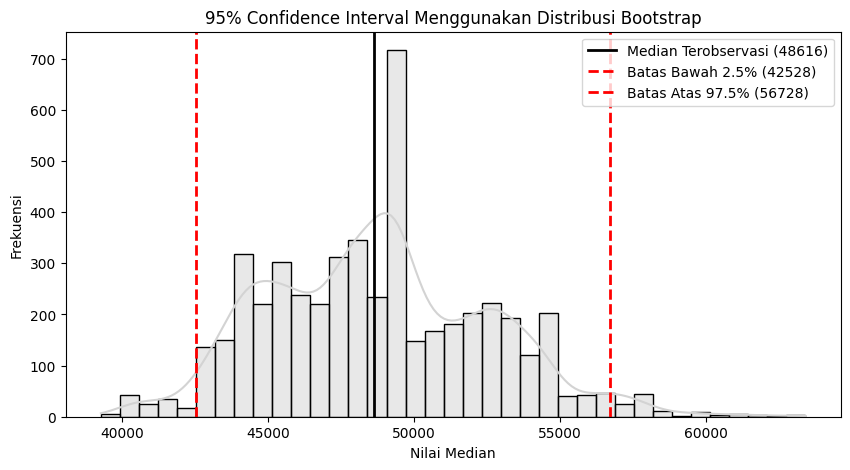

In [6]:
# Menggunakan distribusi median bootstrap dari langkah sebelumnya
ci_lower = np.percentile(bootstrap_medians, 2.5)
ci_upper = np.percentile(bootstrap_medians, 97.5)

print(f"95% Confidence Interval untuk Median: [{ci_lower:.2f}, {ci_upper:.2f}]")

# Visualisasi Interval Kepercayaan
plt.figure(figsize=(10, 5))
sns.histplot(bootstrap_medians, color='lightgray', kde=True)
plt.axvline(observed_median, color='black', linewidth=2, label=f'Median Terobservasi ({observed_median:.0f})')
plt.axvline(ci_lower, color='red', linestyle='dashed', linewidth=2, label=f'Batas Bawah 2.5% ({ci_lower:.0f})')
plt.axvline(ci_upper, color='red', linestyle='dashed', linewidth=2, label=f'Batas Atas 97.5% ({ci_upper:.0f})')
plt.title('95% Confidence Interval Menggunakan Distribusi Bootstrap')
plt.xlabel('Nilai Median')
plt.ylabel('Frekuensi')
plt.legend()
plt.show()


***
## 6. Distribusi Normal dan Evaluasi Melalui QQ-Plot

### Penjelasan Teori

Distribusi normal memiliki karakteristik matematis yang simetris, di mana enam puluh delapan persen data berada dalam satu standar deviasi dari mean, dan sembilan puluh lima persen data berada dalam dua standar deviasi.

Untuk mendeteksi apakah sebuah sebaran data empiris mengikuti asumsi distribusi normal atau tidak, kita menggunakan alat diagnosis visual bernama Quantile-Quantile Plot (QQ-Plot). Grafik ini memetakan nilai kuantil dari data sampel terhadap kuantil teoritis dari distribusi normal standar. Jika data berdistribusi normal, titik-titik data akan sejajar membentuk garis lurus diagonal secara sempurna. Adanya deviasi lengkungan di ujung bawah atau atas menandakan adanya penyimpangan distribusi seperti fenomena ekor tebal (heavy tails).

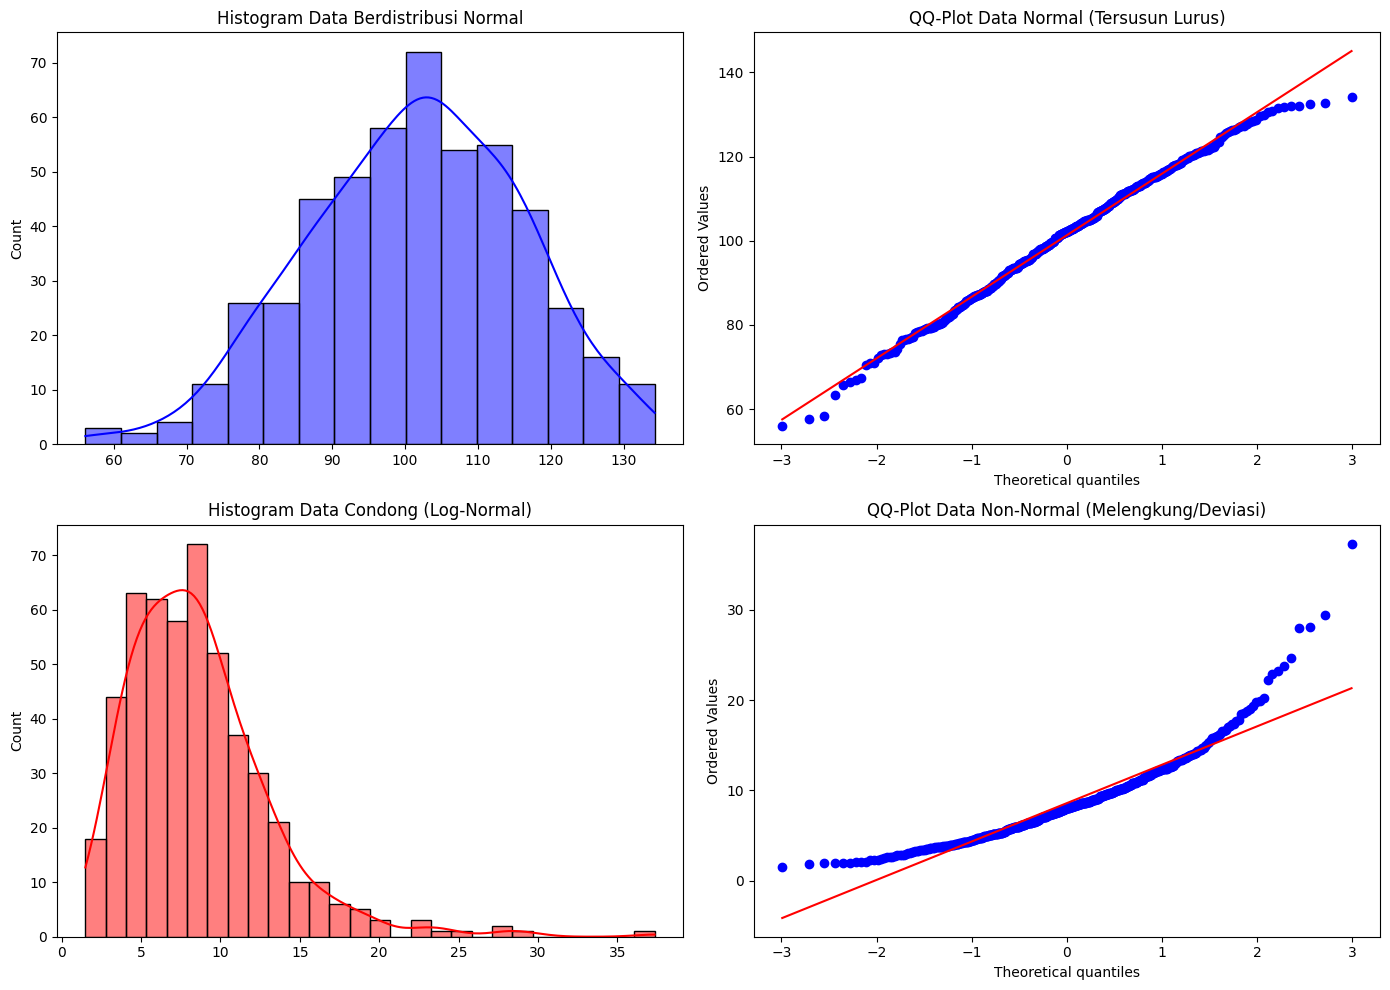

In [7]:
# Membangkitkan dua dataset berbeda untuk uji perbandingan
data_normal = np.random.normal(loc=100, scale=15, size=500)
data_non_normal = np.random.lognormal(mean=2, sigma=0.5, size=500)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Data Normal
sns.histplot(data_normal, kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('Histogram Data Berdistribusi Normal')
stats.probplot(data_normal, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('QQ-Plot Data Normal (Tersusun Lurus)')

# Data Non-Normal
sns.histplot(data_non_normal, kde=True, ax=axes[1, 0], color='red')
axes[1, 0].set_title('Histogram Data Condong (Log-Normal)')
stats.probplot(data_non_normal, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('QQ-Plot Data Non-Normal (Melengkung/Deviasi)')

plt.tight_layout()
plt.show()


***
## 7. Distribusi Spesifik: Binomial, Poisson, dan Eksponensial

### Penjelasan Teori

Selain distribusi normal kontinu, analisis statistik dalam data science sering berhadapan dengan tipe distribusi peluang diskret dan waktu tunggu.

* **Distribusi Binomial:** Digunakan untuk memodelkan jumlah sukses dari k percobaan independen yang bersifat dikotomi (sukses atau gagal), contohnya konversi klik iklan dengan probabilitas p.
* **Distribusi Poisson:** Digunakan untuk menghitung jumlah peristiwa yang terjadi dalam suatu interval waktu atau ruang tertentu dengan laju rata-rata lambda yang konstan, seperti jumlah kunjungan server per menit.
* **Distribusi Eksponensial:** Komplemen langsung dari proses Poisson, yang mengukur durasi atau waktu tunggu kontinu di antara dua peristiwa sukses berurutan.

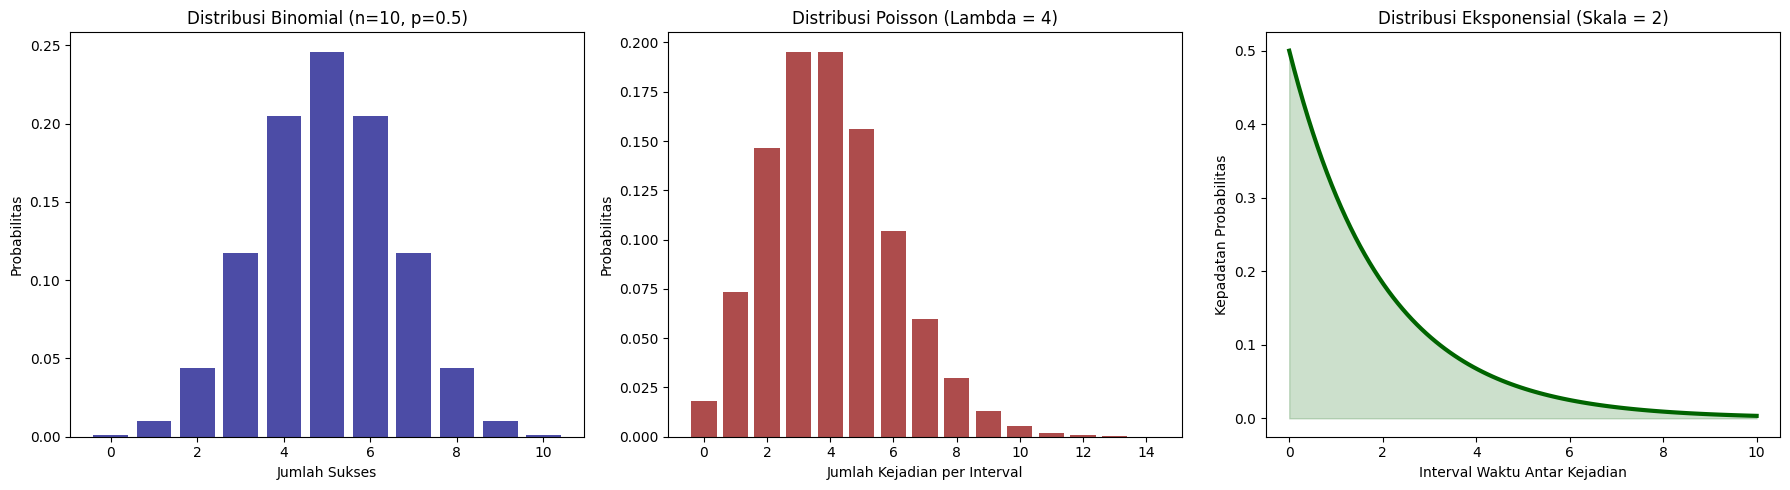

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Simulasi Binomial (n=10 percobaan, probabilitas p=0.5)
n_trials = 10
p_prob = 0.5
x_binom = np.arange(0, n_trials + 1)
y_binom = stats.binom.pmf(x_binom, n_trials, p_prob)
axes[0].bar(x_binom, y_binom, color='navy', alpha=0.7)
axes[0].set_title('Distribusi Binomial (n=10, p=0.5)')
axes[0].set_xlabel('Jumlah Sukses')
axes[0].set_ylabel('Probabilitas')

# 2. Simulasi Poisson (Rata-rata lambda = 4 kejadian per interval)
lam_rate = 4
x_poisson = np.arange(0, 15)
y_poisson = stats.poisson.pmf(x_poisson, lam_rate)
axes[1].bar(x_poisson, y_poisson, color='darkred', alpha=0.7)
axes[1].set_title('Distribusi Poisson (Lambda = 4)')
axes[1].set_xlabel('Jumlah Kejadian per Interval')
axes[1].set_ylabel('Probabilitas')

# 3. Simulasi Eksponensial (Waktu antar kejadian dengan skala beta = 2)
scale_beta = 2
x_expon = np.linspace(0, 10, 100)
y_expon = stats.expon.pdf(x_expon, scale=scale_beta)
axes[2].plot(x_expon, y_expon, color='darkgreen', linewidth=3)
axes[2].fill_between(x_expon, y_expon, color='darkgreen', alpha=0.2)
axes[2].set_title('Distribusi Eksponensial (Skala = 2)')
axes[2].set_xlabel('Interval Waktu Antar Kejadian')
axes[2].set_ylabel('Kepadatan Probabilitas')

plt.tight_layout()
plt.show()
